# 03 — Análise Macroeconômica

**Objetivo:** comparar o USD/BRL com os principais indicadores macroeconômicos e contextualizar os movimentos cambiais com eventos históricos relevantes.

**Entradas:** `data/processed/dataset_analitico.csv`  
**Saídas:** gráficos em `reports/figures/`

---

## 0. Setup

In [13]:
import sys
from pathlib import Path
sys.path.append(str(Path('..') / 'src'))

import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from load import load_dataset
from plots import plot_dual_axis, set_style

pd.set_option('display.float_format', '{:.4f}'.format)
set_style()

# Ajuste fino da identidade visual deste notebook
plt.rcParams.update({
    'axes.titlepad': 16,
    'axes.grid': True,
    'grid.alpha': 0.35,
    'grid.linestyle': '--',
    'lines.linewidth': 1.6,
    'legend.frameon': True,
    'legend.fancybox': True,
    'legend.borderpad': 0.6,
})

df = load_dataset()
print(f'Dataset: {df.shape[0]} meses × {df.shape[1]} colunas')

2026-04-11 00:14:40 | INFO     | load | Dataset carregado: 175 meses × 12 colunas


Dataset: 175 meses × 12 colunas


## 1. USD/BRL × Selic

**Hipótese H4:** quando a Selic está alta em relação aos juros americanos, o real tende a se valorizar — e vice-versa.

2026-04-11 00:11:09 | INFO     | plots | Figura salva: C:\Users\edupe\usd-brl-analysis-2010-2026\reports\figures\03_cambio_x_selic.png


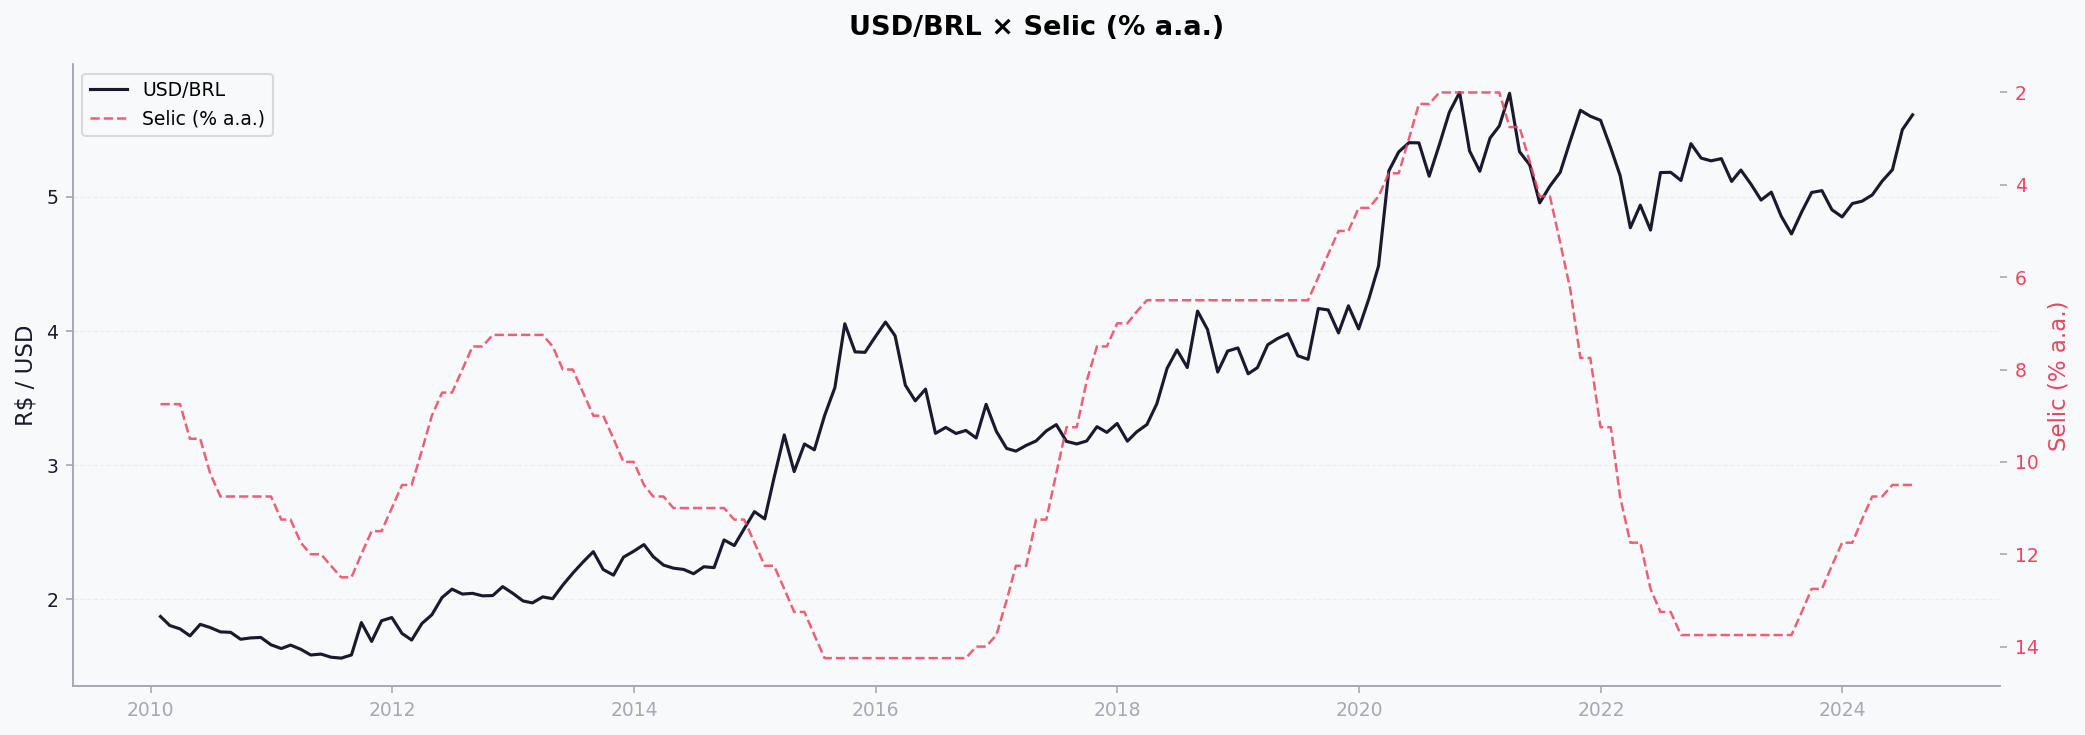

In [2]:
fig = plot_dual_axis(
    df,
    col_macro='selic',
    label_macro='Selic (% a.a.)',
    invert_macro=True,   # eixo invertido: Selic alta → BRL mais forte
    filename='03_cambio_x_selic'
)
plt.show()

## 2. USD/BRL × Spread de Juros (Selic − Fed Funds)

**Hipótese H4:** quando o spread se estreita (Fed sobe juros enquanto Selic cai), o real tende a se depreciar.

In [4]:
if 'spread_juros' in df.columns:
    fig = plot_dual_axis(
        df,
        col_macro='spread_juros',
        label_macro='Spread Selic − Fed Funds (p.p.)',
        invert_macro=True,
        filename='03_cambio_x_spread_juros',
    )
    plt.show()
else:
    print("Coluna 'spread_juros' não disponível no dataset atual.")
    print("Dica: gere fed_funds para habilitar este gráfico.")

Coluna 'spread_juros' não disponível no dataset atual.
Dica: gere fed_funds para habilitar este gráfico.


## 3. USD/BRL × Fed Funds Rate

**Hipótese H2:** ciclos de alta dos juros americanos pressionam moedas emergentes.

In [5]:
if 'fed_funds' in df.columns:
    fig = plot_dual_axis(
        df,
        col_macro='fed_funds',
        label_macro='Fed Funds Rate (% a.a.)',
        filename='03_cambio_x_fed_funds',
    )
    plt.show()
else:
    print("Coluna 'fed_funds' não disponível no dataset atual.")
    print("Dica: configure FRED_API_KEY e rode a coleta novamente.")

Coluna 'fed_funds' não disponível no dataset atual.
Dica: configure FRED_API_KEY e rode a coleta novamente.


## 4. USD/BRL × DXY (Índice do Dólar)

Separa o efeito do **fortalecimento global do dólar** do efeito de fatores domésticos sobre o BRL.

2026-04-11 00:11:50 | INFO     | plots | Figura salva: C:\Users\edupe\usd-brl-analysis-2010-2026\reports\figures\03_cambio_x_dxy.png


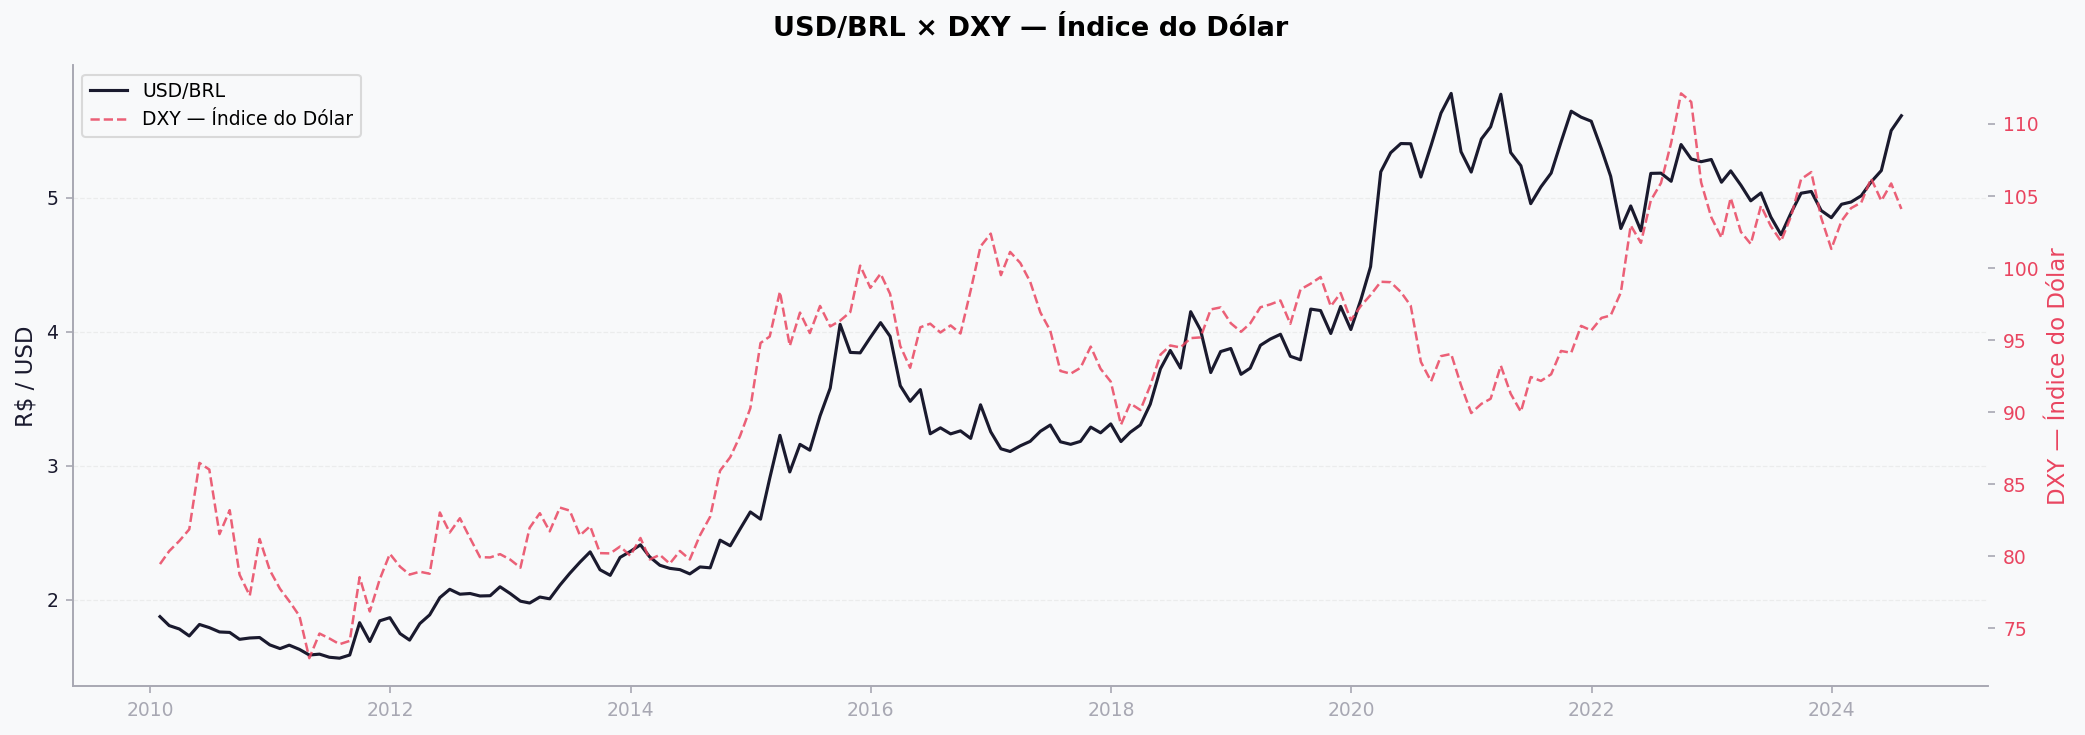

In [6]:
fig = plot_dual_axis(
    df,
    col_macro='dxy',
    label_macro='DXY — Índice do Dólar',
    filename='03_cambio_x_dxy'
)
plt.show()

## 5. USD/BRL × IPCA acumulado 12 meses

Inflação doméstica elevada corrói o poder de compra do real e pode pressionar o câmbio.

2026-04-11 00:11:50 | INFO     | plots | Figura salva: C:\Users\edupe\usd-brl-analysis-2010-2026\reports\figures\03_cambio_x_ipca.png


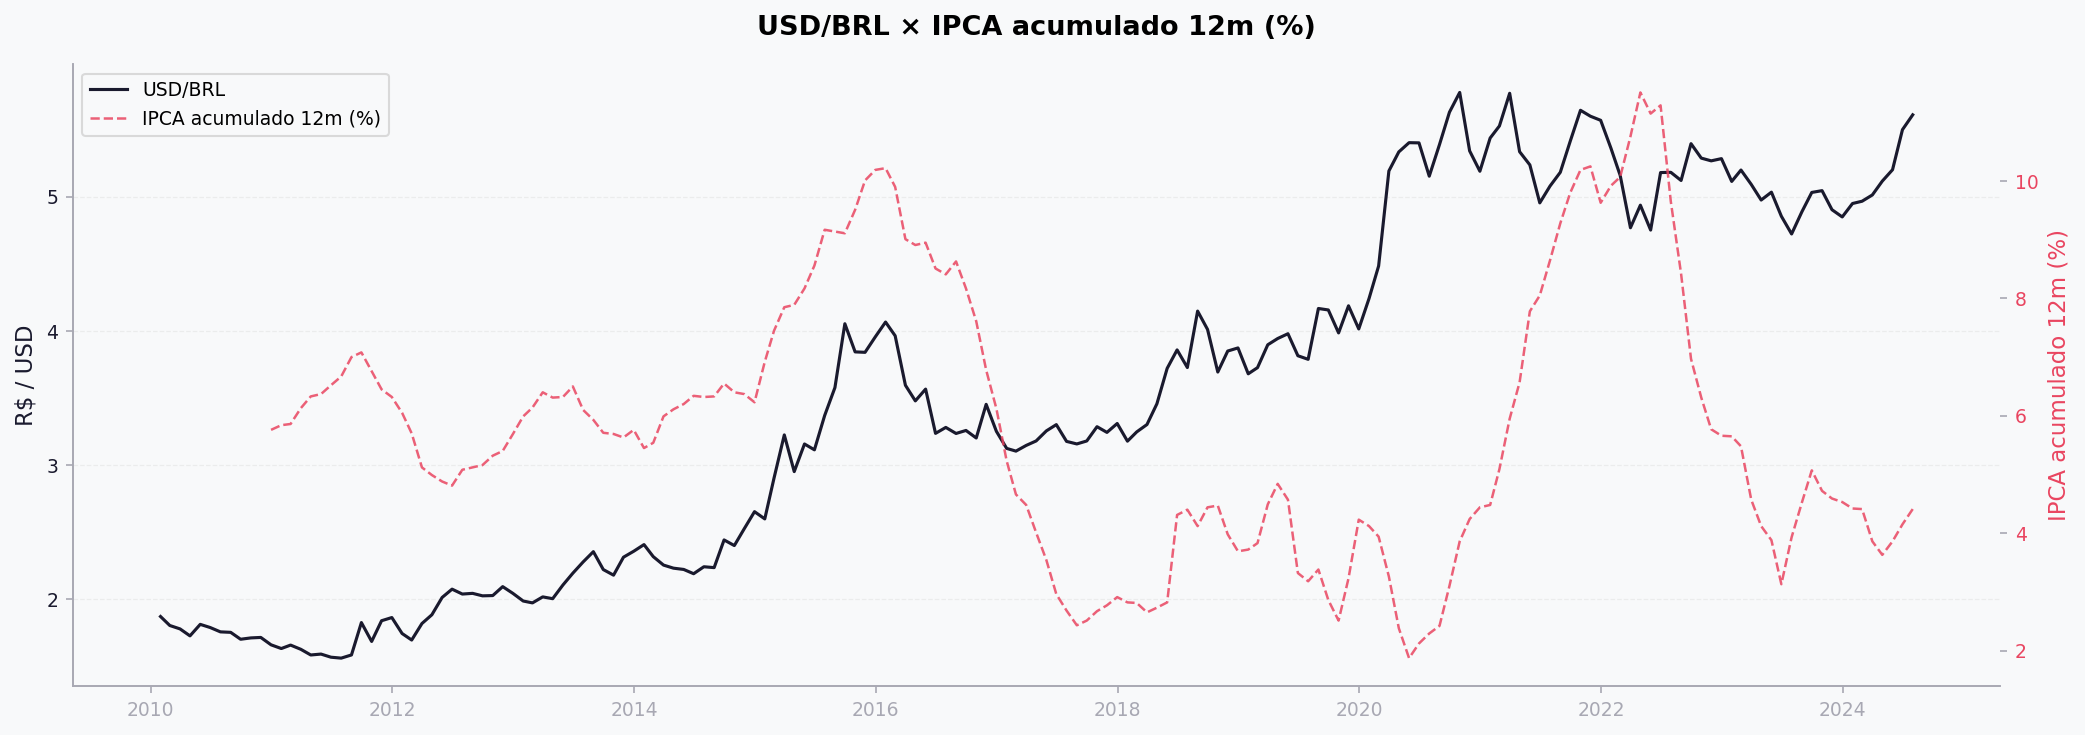

In [7]:
fig = plot_dual_axis(
    df,
    col_macro='ipca_acumulado_12m',
    label_macro='IPCA acumulado 12m (%)',
    filename='03_cambio_x_ipca'
)
plt.show()

## 6. USD/BRL × Ibovespa

**Hipótese H1:** em períodos de instabilidade, o Ibovespa cai e o dólar sobe simultaneamente — correlação negativa esperada.

2026-04-11 00:11:51 | INFO     | plots | Figura salva: C:\Users\edupe\usd-brl-analysis-2010-2026\reports\figures\03_cambio_x_ibovespa.png


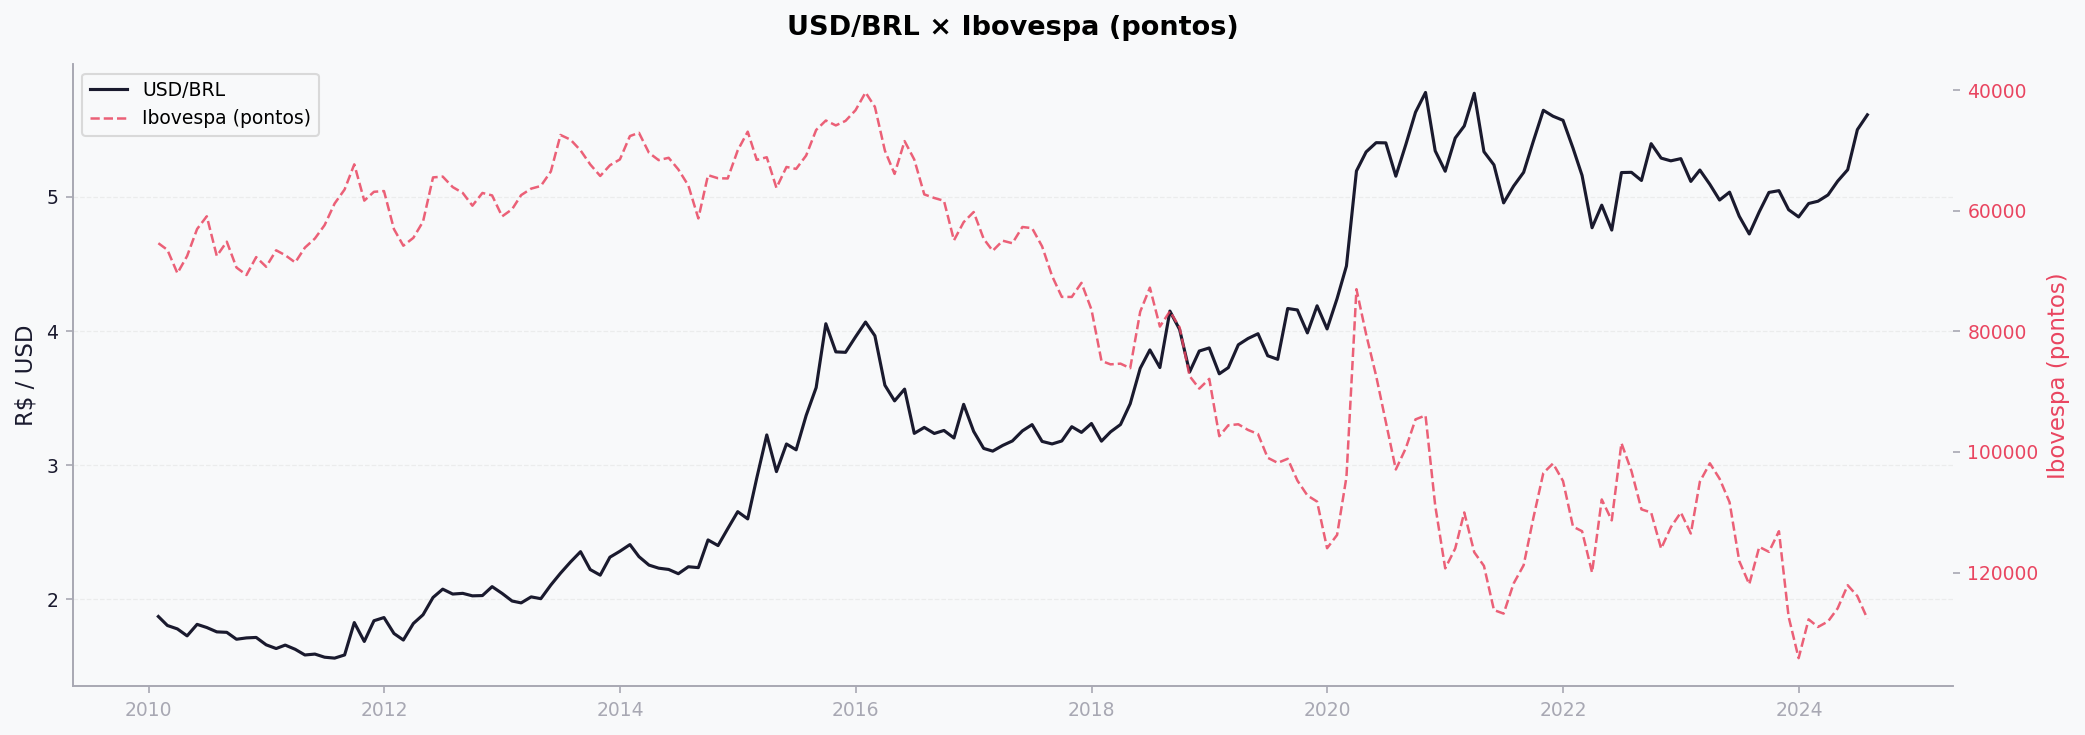

In [8]:
fig = plot_dual_axis(
    df,
    col_macro='ibovespa',
    label_macro='Ibovespa (pontos)',
    invert_macro=True,
    filename='03_cambio_x_ibovespa'
)
plt.show()

## 7. USD/BRL × VIX

**Hipótese H3:** picos do VIX (medo global) coincidem com fortes altas do dólar frente ao real.

2026-04-11 00:12:01 | INFO     | plots | Figura salva: C:\Users\edupe\usd-brl-analysis-2010-2026\reports\figures\03_cambio_x_vix.png


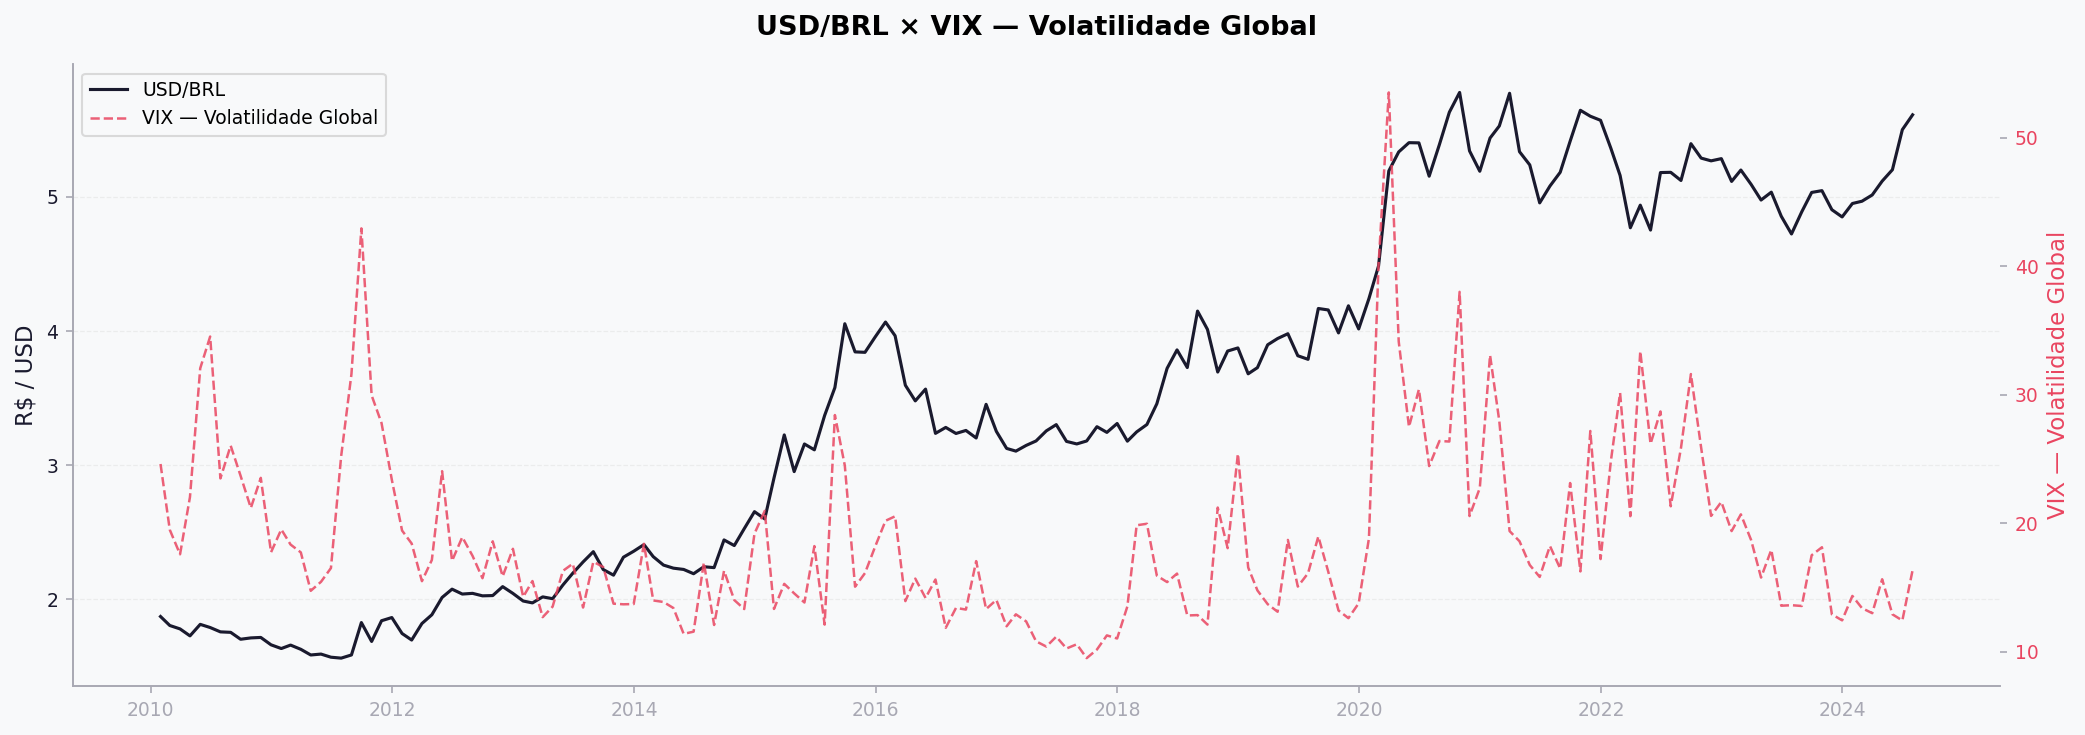

In [9]:
fig = plot_dual_axis(
    df,
    col_macro='vix',
    label_macro='VIX — Volatilidade Global',
    filename='03_cambio_x_vix'
)
plt.show()

## 8. USD/BRL × EMBI+ Brasil

**Hipótese H1:** o risco-país reflete a percepção dos investidores sobre a estabilidade fiscal e política do Brasil.

2026-04-11 00:12:02 | INFO     | plots | Figura salva: C:\Users\edupe\usd-brl-analysis-2010-2026\reports\figures\03_cambio_x_embi.png


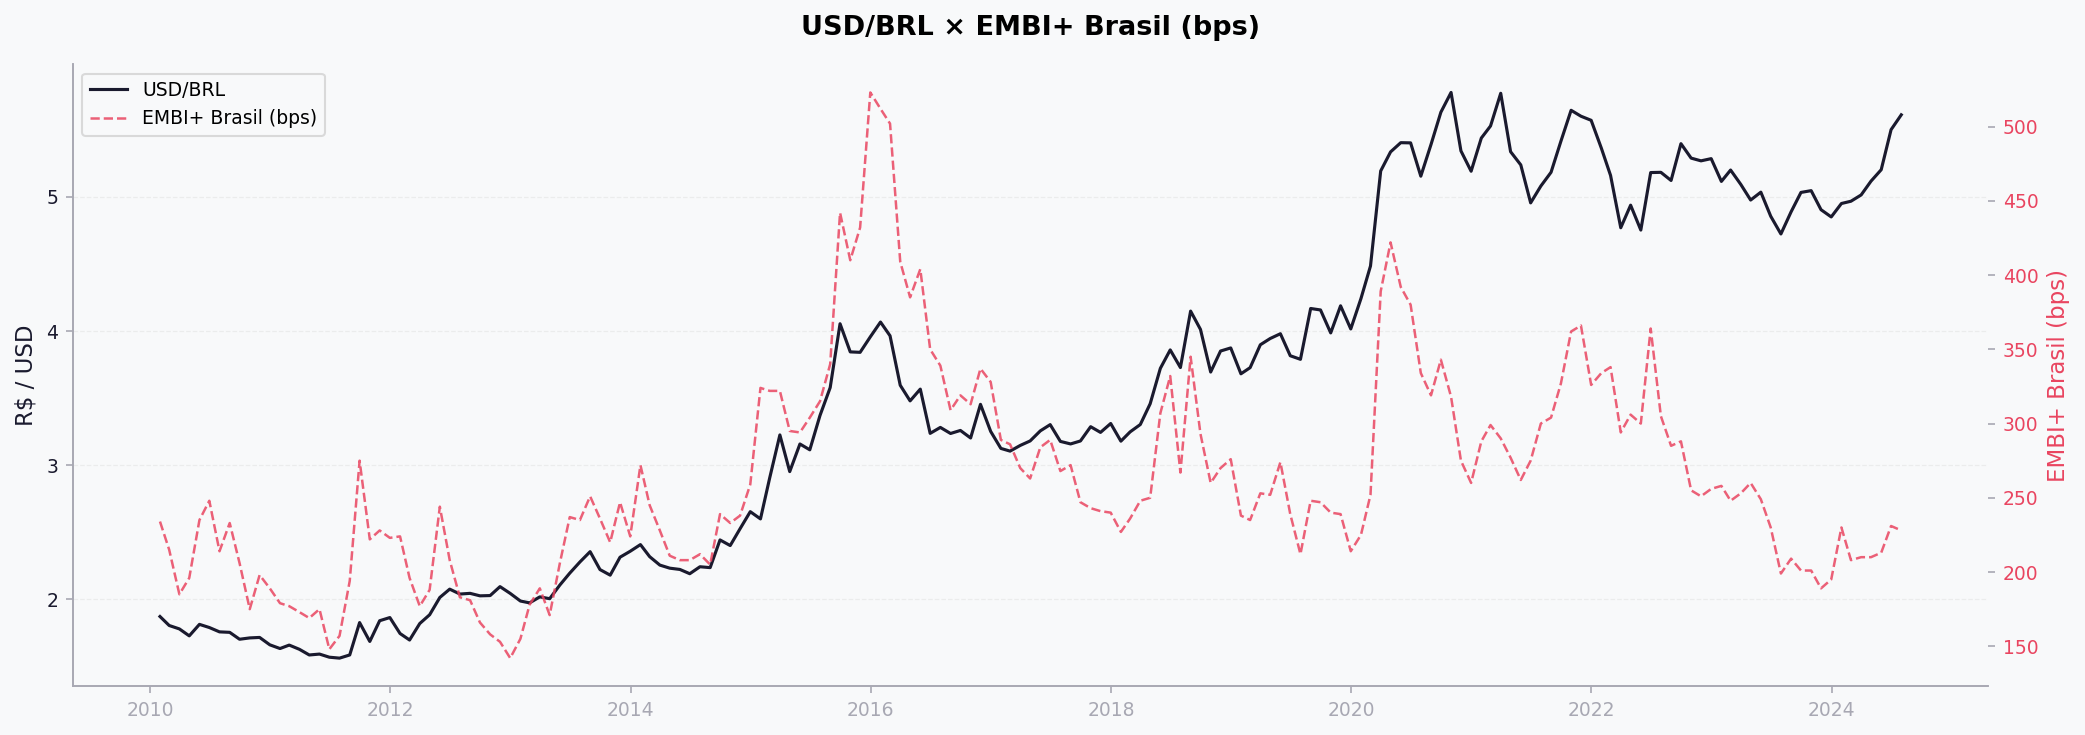

In [10]:
fig = plot_dual_axis(
    df,
    col_macro='embi_brasil',
    label_macro='EMBI+ Brasil (bps)',
    filename='03_cambio_x_embi'
)
plt.show()

## 9. USD/BRL × Petróleo WTI

O Brasil é exportador de petróleo. Quedas no preço do petróleo reduzem receitas em dólares e podem pressionar o real.

2026-04-11 00:12:02 | INFO     | plots | Figura salva: C:\Users\edupe\usd-brl-analysis-2010-2026\reports\figures\03_cambio_x_petroleo.png


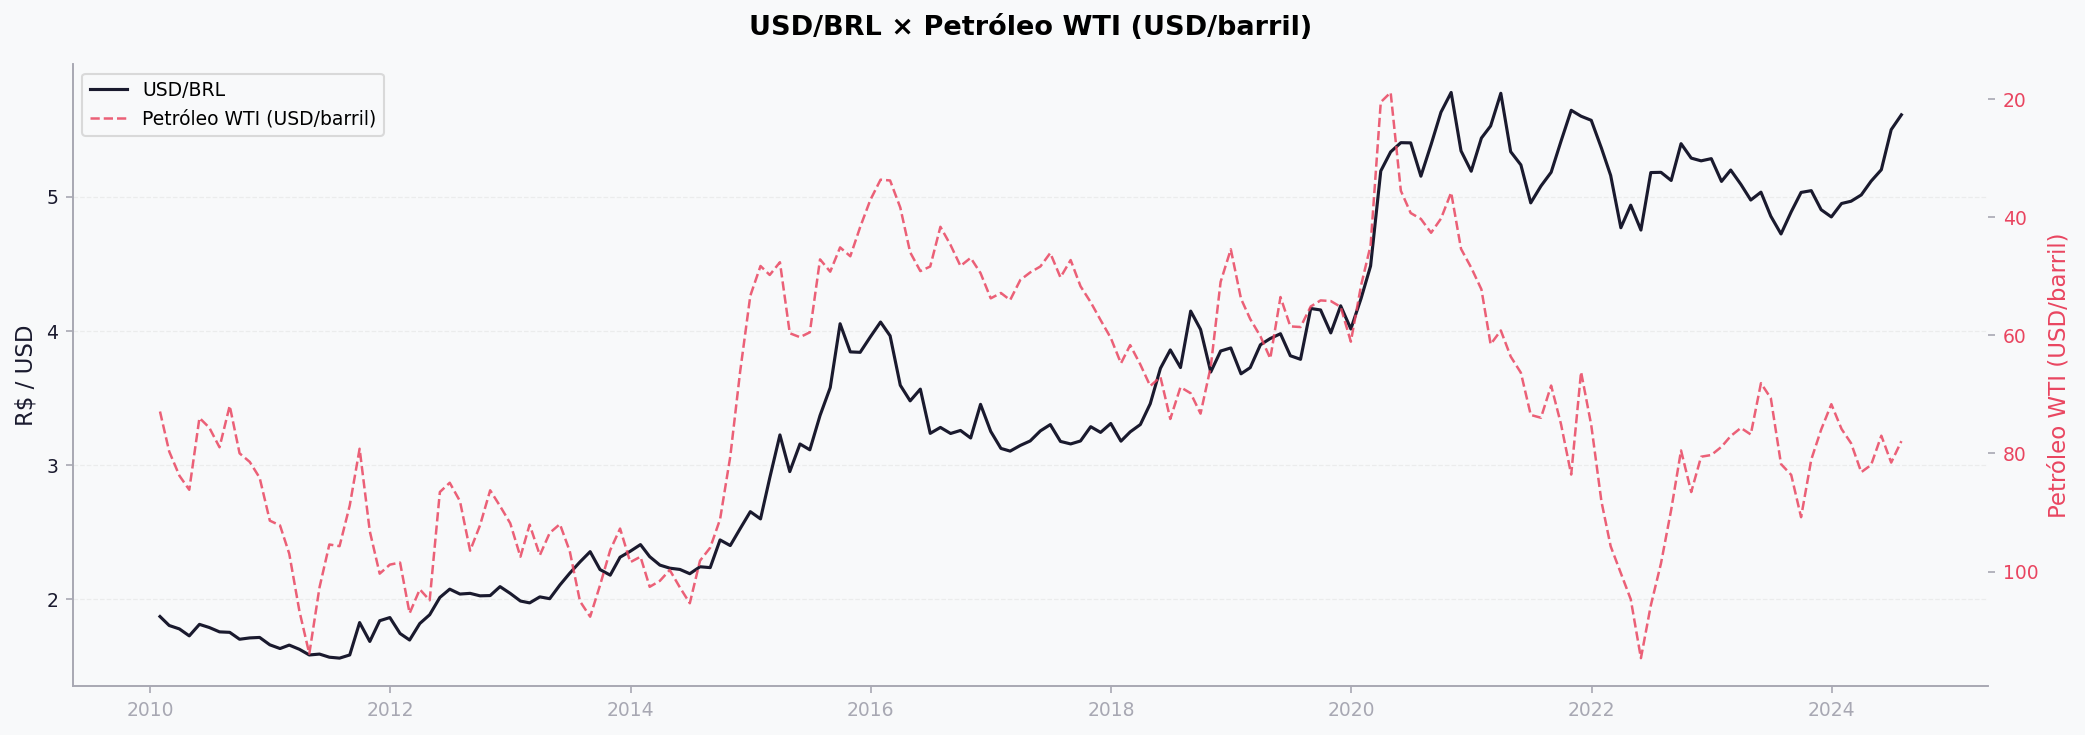

In [11]:
fig = plot_dual_axis(
    df,
    col_macro='petroleo_wti',
    label_macro='Petróleo WTI (USD/barril)',
    invert_macro=True,
    filename='03_cambio_x_petroleo'
)
plt.show()

## 10. Painel consolidado — todos os gráficos de eixo duplo

Visão compacta para comparar padrões visuais entre variáveis.

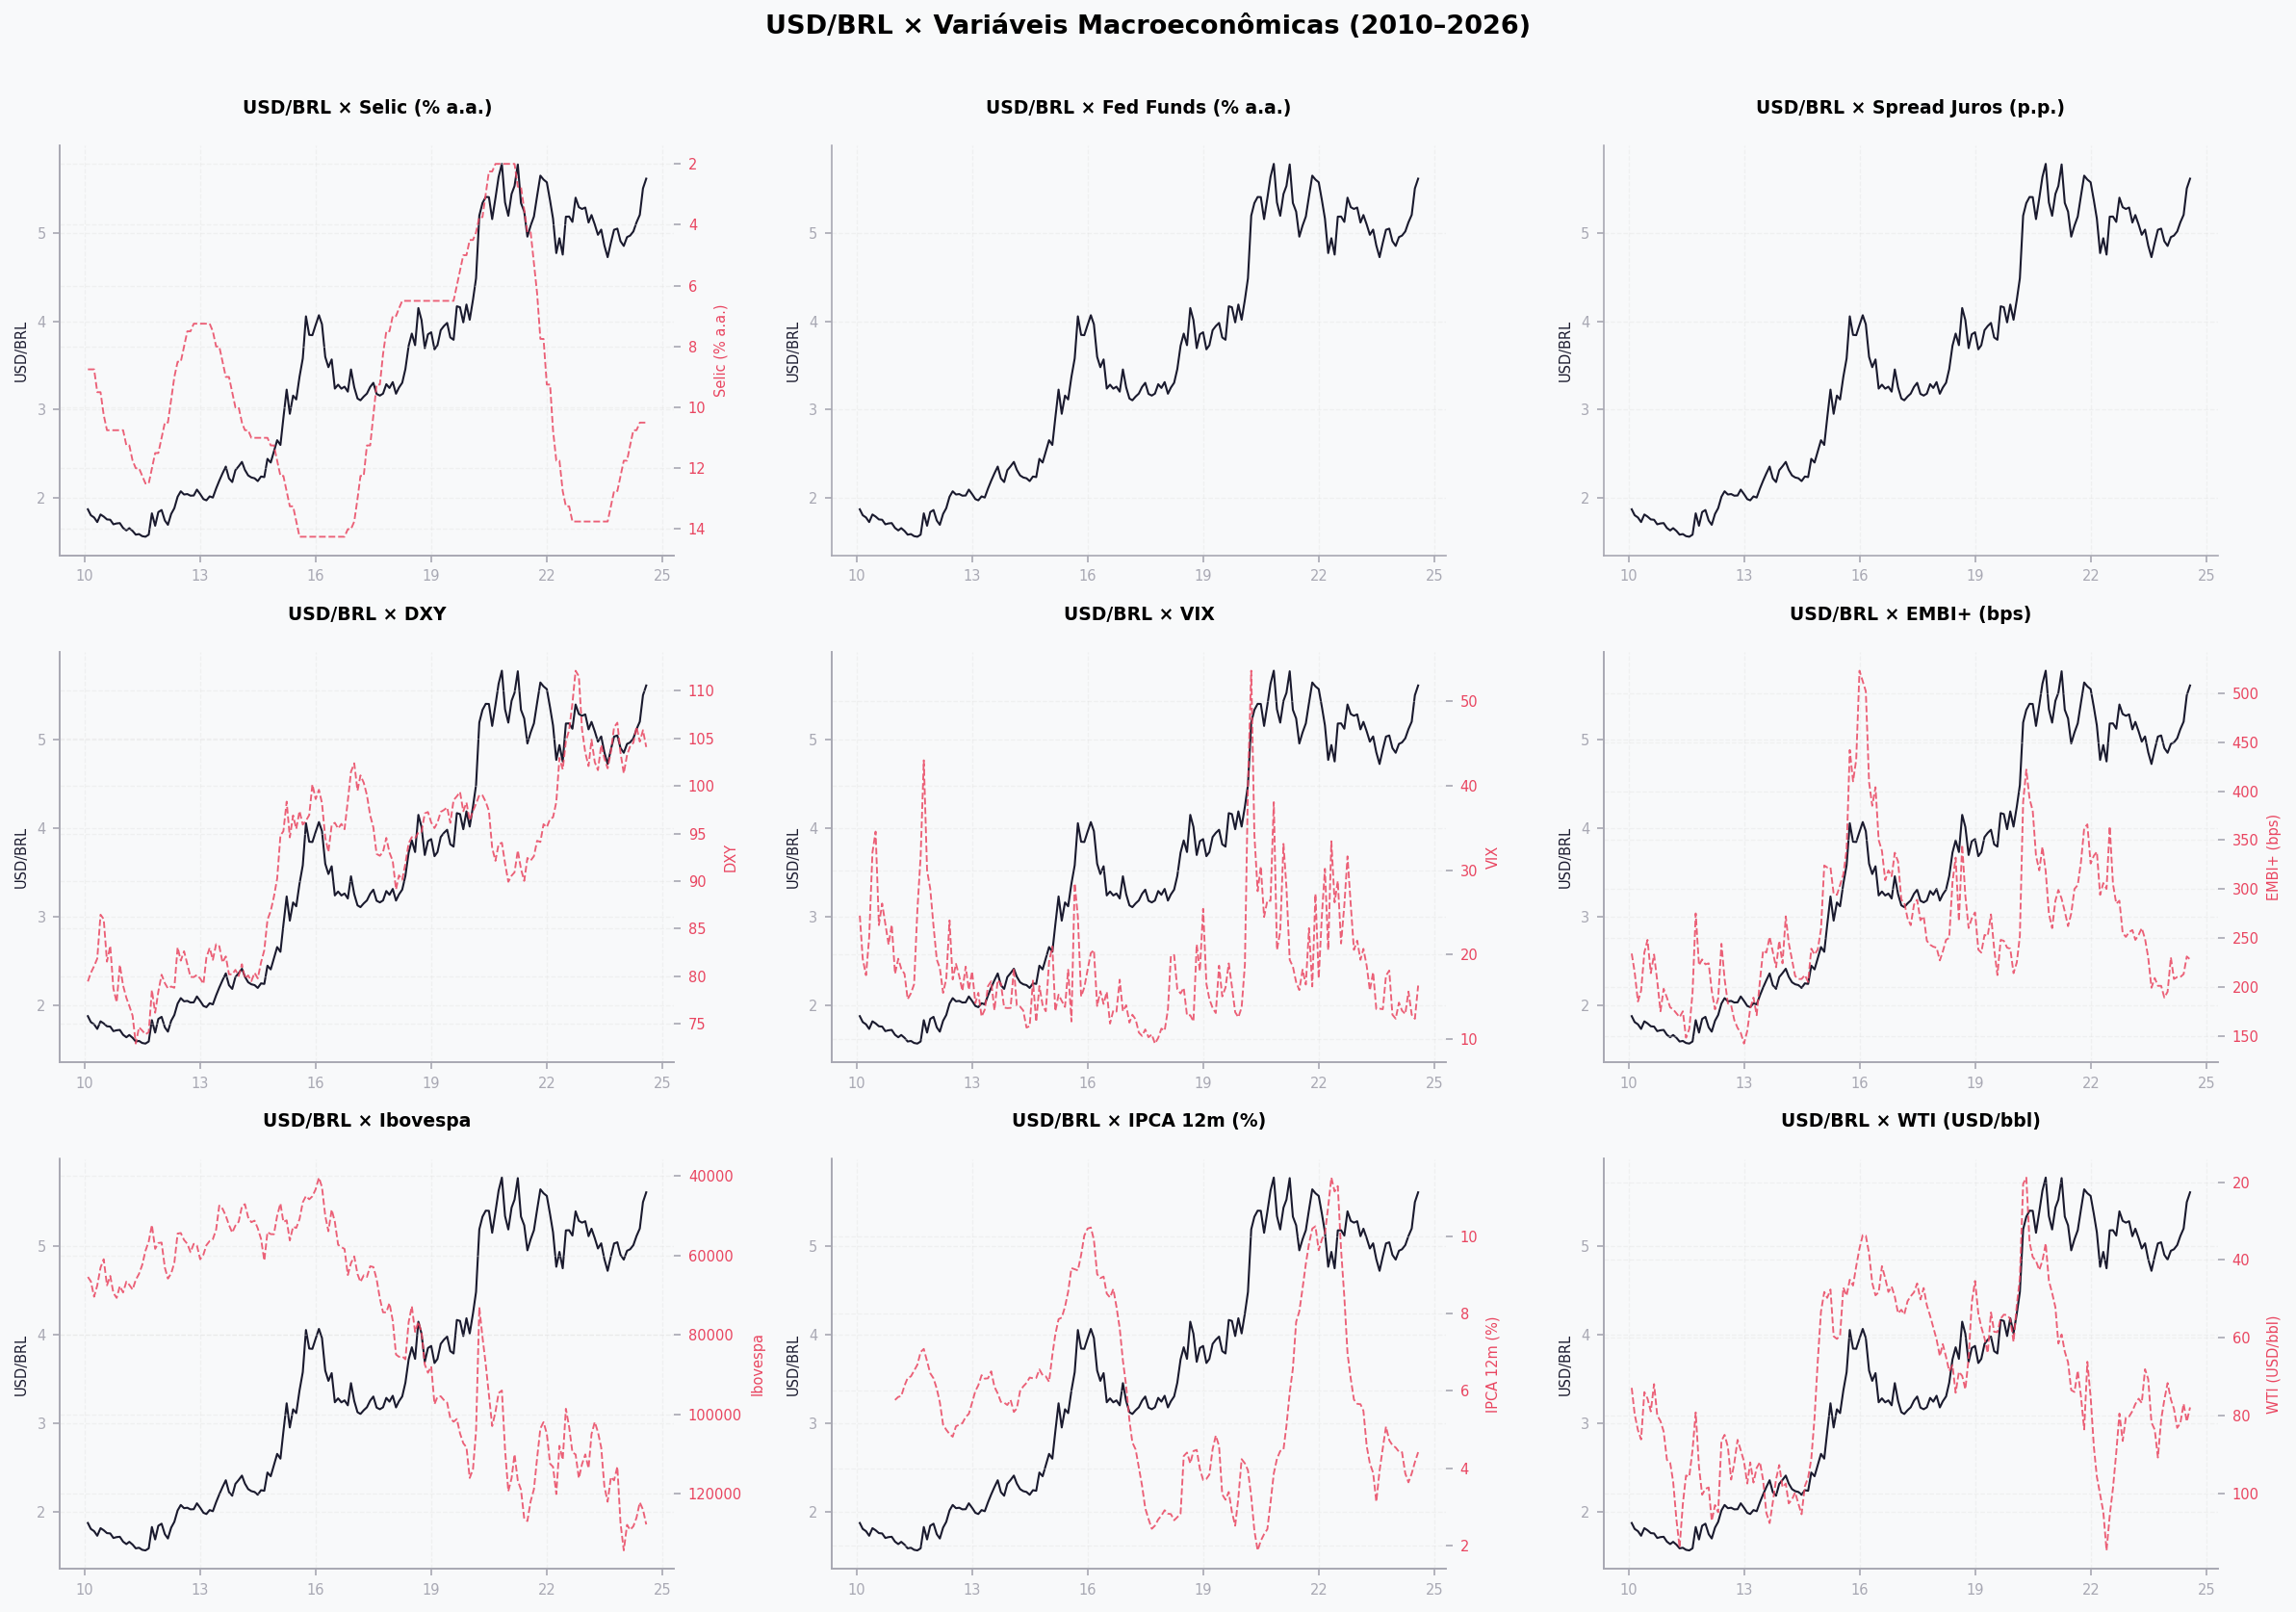

In [14]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from plots import PALETTE

macros = [
    ('selic',             'Selic (% a.a.)',          True),
    ('fed_funds',         'Fed Funds (% a.a.)',       False),
    ('spread_juros',      'Spread Juros (p.p.)',      True),
    ('dxy',               'DXY',                     False),
    ('vix',               'VIX',                     False),
    ('embi_brasil',       'EMBI+ (bps)',              False),
    ('ibovespa',          'Ibovespa',                 True),
    ('ipca_acumulado_12m','IPCA 12m (%)',             False),
    ('petroleo_wti',      'WTI (USD/bbl)',            True),
]

fig, axes = plt.subplots(3, 3, figsize=(16, 11))
axes = axes.flatten()

for i, (col, label, invert) in enumerate(macros):
    ax1 = axes[i]
    s_cambio = df['usd_brl'].dropna()
    s_macro  = df[col].dropna() if col in df.columns else None

    ax1.plot(s_cambio.index, s_cambio.values,
             color=PALETTE['primary'], linewidth=1, label='USD/BRL')
    ax1.set_ylabel('USD/BRL', fontsize=7, color=PALETTE['primary'])
    ax1.tick_params(axis='y', labelsize=7)
    ax1.xaxis.set_major_formatter(mdates.DateFormatter("%y"))
    ax1.xaxis.set_major_locator(mdates.YearLocator(3))
    ax1.tick_params(axis='x', labelsize=7)

    if s_macro is not None:
        ax2 = ax1.twinx()
        ax2.plot(s_macro.index, s_macro.values,
                 color=PALETTE['accent'], linewidth=0.9,
                 linestyle='--', alpha=0.85)
        ax2.set_ylabel(label, fontsize=7, color=PALETTE['accent'])
        ax2.tick_params(axis='y', labelsize=7, labelcolor=PALETTE['accent'])
        if invert:
            ax2.invert_yaxis()

    ax1.set_title(f'USD/BRL × {label}', fontsize=9, fontweight='bold')
    ax1.spines['top'].set_visible(False)

fig.suptitle('USD/BRL × Variáveis Macroeconômicas (2010–2026)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../reports/figures/03_painel_macro.png', dpi=300, bbox_inches='tight')
plt.show()

## 10. Auditoria rápida de consistência dos dados

Checagem objetiva de qualidade do dataset final:

- cobertura temporal e frequência mensal
- valores faltantes por coluna
- índice temporal monotônico e duplicado
- outliers robustos por IQR (contagem)

In [15]:
# Auditoria de consistência do dataset
df_check = df.copy()

print('=== COBERTURA TEMPORAL ===')
inicio = df_check.index.min()
fim = df_check.index.max()
print(f'Período: {inicio:%Y-%m} até {fim:%Y-%m}')
print(f'Observações: {len(df_check)}')

print('\n=== ÍNDICE TEMPORAL ===')
print(f'Monotônico crescente: {df_check.index.is_monotonic_increasing}')
print(f'Datas duplicadas: {int(df_check.index.duplicated().sum())}')

freq = pd.infer_freq(df_check.index)
print(f'Frequência inferida: {freq if freq else "não identificada"}')

print('\n=== VALORES FALTANTES ===')
na_count = df_check.isna().sum().sort_values(ascending=False)
na_pct = (df_check.isna().mean() * 100).sort_values(ascending=False)
na_table = pd.DataFrame({
    'faltantes': na_count,
    'faltantes_%': na_pct.round(2),
})
print(na_table[na_table['faltantes'] > 0].head(12))

print('\n=== OUTLIERS ROBUSTOS (IQR) ===')
num_cols = df_check.select_dtypes(include='number').columns
outlier_rows = []
for col in num_cols:
    s = df_check[col].dropna()
    if len(s) < 12:
        continue
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    if iqr == 0:
        continue
    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    out_count = int(((s < low) | (s > high)).sum())
    outlier_rows.append((col, out_count))

outlier_df = pd.DataFrame(outlier_rows, columns=['coluna', 'outliers'])
outlier_df = outlier_df.sort_values('outliers', ascending=False)
print(outlier_df.head(10).to_string(index=False) if not outlier_df.empty else 'Sem outliers detectados pelo critério IQR.')

=== COBERTURA TEMPORAL ===
Período: 2010-01 até 2024-07
Observações: 175

=== ÍNDICE TEMPORAL ===
Monotônico crescente: True
Datas duplicadas: 0
Frequência inferida: ME

=== VALORES FALTANTES ===
                      faltantes  faltantes_%
ipca_acumulado_12m           11       6.2900
usd_brl_volatilidade          3       1.7100
usd_brl_retorno               1       0.5700

=== OUTLIERS ROBUSTOS (IQR) ===
              coluna  outliers
                 vix         8
         embi_brasil         5
     usd_brl_retorno         4
usd_brl_volatilidade         3
  ipca_acumulado_12m         3
         ipca_mensal         2
             usd_brl         0
            ibovespa         0
                 dxy         0
               selic         0


## 11. Conclusão

**Observações preliminares (preencher após execução):**

- USD/BRL × Selic: *[descrever padrão observado]*
- USD/BRL × Fed Funds: *[descrever padrão observado]*
- USD/BRL × VIX: *[descrever padrão observado]*
- USD/BRL × EMBI+: *[descrever padrão observado]*
- USD/BRL × Ibovespa: *[descrever padrão observado]*

Próximo passo: **Notebook 04 — Correlações e Modelagem**.